# Airports case study - solution

In [1]:
import pandas as pd
import seaborn as sns

## Get the data

In [2]:
# NOTE: Setting the low_memory parameter to False fixes a warning.
tsaClaims = pd.read_csv('data/tsa_claims1.csv', low_memory=False)

## Examine the data

In [3]:
tsaClaims.head()

,Claim Number,Date Received,Incident Date,Airport Code,Airport Name,Airline Name,Claim Type,Claim Site,Item,Claim Amount,Status,Close Amount,Disposition
0,0909802M,4-Jan-02,12/12/2002 0:00,EWR,Newark International Airport,Continental Airlines,Property Damage,Checkpoint,Other,350.00,Approved,350.00,Approve in Full
1,0202445M,4-Feb-02,11/26/2003 0:00,STL,Lambert St. Louis International,American Airlines,Property Damage,Checked Baggage,Cell Phones,278.88,Settled,227.92,Settle
2,0909816M,7-Feb-02,1/6/2003 0:00,MIA,Miami International Airport,American Airlines,Property Damage,Checkpoint,Luggage (all types including footlockers),50.00,Approved,50.00,Approve in Full
3,2005032379513,18-Feb-02,2/5/2005 0:00,MCO,Orlando International Airport,Delta (Song),Property Damage,Checkpoint,Baby - Strollers; car seats; playpen; etc.,84.79,Approved,84.79,Approve in Full
4,2005032479636,18-Feb-02,2/17/2005 0:00,CAK,Akron-Canton Regional,Air Tran Airlines(do not use),Passenger Property Loss,Checked Baggage,Other,459.01,Settled,227.00,Settle


In [4]:
tsaClaims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94848 entries, 0 to 94847
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Claim Number   94848 non-null  object 
 1   Date Received  94848 non-null  object 
 2   Incident Date  94848 non-null  object 
 3   Airport Code   94848 non-null  object 
 4   Airport Name   94848 non-null  object 
 5   Airline Name   94848 non-null  object 
 6   Claim Type     94848 non-null  object 
 7   Claim Site     94848 non-null  object 
 8   Item           94848 non-null  object 
 9   Claim Amount   94848 non-null  float64
 10  Status         94848 non-null  object 
 11  Close Amount   94848 non-null  float64
 12  Disposition    94848 non-null  object 
dtypes: float64(2), object(11)
memory usage: 9.4+ MB


In [5]:
tsaClaims.nunique()

Claim Number     94848
Date Received     2014
Incident Date     3882
Airport Code       411
Airport Name       411
Airline Name       186
Claim Type           6
Claim Site           4
Item              3072
Claim Amount     27013
Status               5
Close Amount     13571
Disposition          3
dtype: int64

## Clean the data

In [6]:
# To make it easier to work with columns, remove spaces from column names.
tsaClaims.columns = tsaClaims.columns.str.replace(' ','')

In [7]:
tsaClaims.head()

,ClaimNumber,DateReceived,IncidentDate,AirportCode,AirportName,AirlineName,ClaimType,ClaimSite,Item,ClaimAmount,Status,CloseAmount,Disposition
0,0909802M,4-Jan-02,12/12/2002 0:00,EWR,Newark International Airport,Continental Airlines,Property Damage,Checkpoint,Other,350.00,Approved,350.00,Approve in Full
1,0202445M,4-Feb-02,11/26/2003 0:00,STL,Lambert St. Louis International,American Airlines,Property Damage,Checked Baggage,Cell Phones,278.88,Settled,227.92,Settle
2,0909816M,7-Feb-02,1/6/2003 0:00,MIA,Miami International Airport,American Airlines,Property Damage,Checkpoint,Luggage (all types including footlockers),50.00,Approved,50.00,Approve in Full
3,2005032379513,18-Feb-02,2/5/2005 0:00,MCO,Orlando International Airport,Delta (Song),Property Damage,Checkpoint,Baby - Strollers; car seats; playpen; etc.,84.79,Approved,84.79,Approve in Full
4,2005032479636,18-Feb-02,2/17/2005 0:00,CAK,Akron-Canton Regional,Air Tran Airlines(do not use),Passenger Property Loss,Checked Baggage,Other,459.01,Settled,227.00,Settle


## Analyze the data

### What is the most common type of claim?

In [8]:
# Group by ClaimType and count the number of claims for each type
claimType = tsaClaims.groupby('ClaimType').count()[['ClaimNumber']]

# Reset the index so the ClaimType column can be used by Seaborn
claimType.reset_index(inplace=True)

claimType

,ClaimType,ClaimNumber
0,Employee Loss (MPCECA),308
1,Motor Vehicle,6
2,Passenger Property Loss,60265
3,Passenger Theft,331
4,Personal Injury,208
5,Property Damage,33730


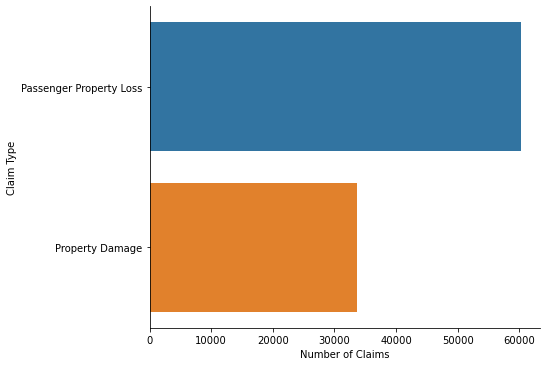

In [9]:
# Plot all claim types that have more than 400 rows...this removes the less common claim types|
g = sns.catplot(data=claimType.query('ClaimNumber > 400'), kind='bar', 
                x='ClaimNumber', y='ClaimType', orient='h', aspect=1.5)

for ax in g.axes.flat:
     ax.set(ylabel='Claim Type', 
            xlabel='Number of Claims')

#### Passenger Property Loss is the most common claim type.

### Which claim site is the most common?

In [10]:
# Group by ClaimType and count the number of claims for each type.
claimSite = tsaClaims.groupby('ClaimSite').count()[['ClaimNumber']].reset_index()
claimSite

,ClaimSite,ClaimNumber
0,Checked Baggage,80553
1,Checkpoint,14013
2,Motor Vehicle,2
3,Other,280


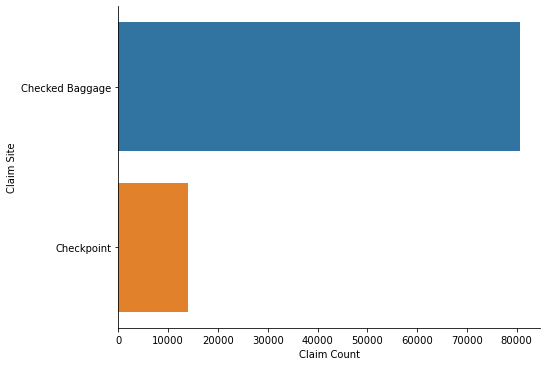

In [11]:
g = sns.catplot(data=claimSite.query('ClaimNumber > 300'), kind='bar', 
                x='ClaimNumber', y='ClaimSite', orient='h', aspect=1.5)

for ax in g.axes.flat:
    ax.set(ylabel='Claim Site', xlabel='Claim Count')

#### The Checked Baggage site is the most common claim site.

### Which type of claim is typically made at each claim site?

In [12]:
claimTypeBySite = tsaClaims.groupby(['ClaimType','ClaimSite']).ClaimNumber.count().reset_index()
claimTypeBySite = claimTypeBySite.query('ClaimNumber > 300')
claimTypeBySite

,ClaimType,ClaimSite,ClaimNumber
6,Passenger Property Loss,Checked Baggage,53364
7,Passenger Property Loss,Checkpoint,6740
16,Property Damage,Checked Baggage,26527
17,Property Damage,Checkpoint,7092


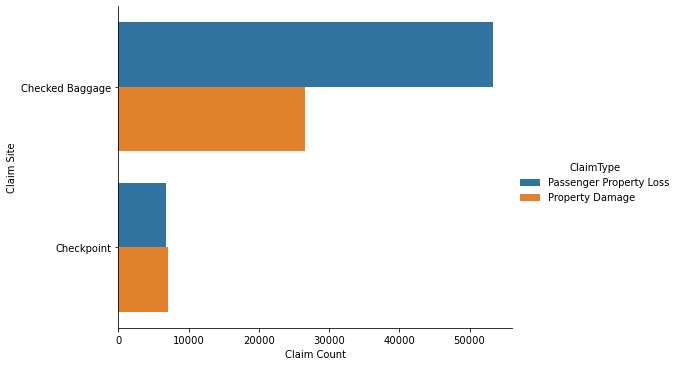

In [13]:
g = sns.catplot(data=claimTypeBySite, kind='bar', 
            x='ClaimNumber', y='ClaimSite', hue='ClaimType', orient='h', aspect=1.5)

for ax in g.axes.flat:
    ax.set(ylabel='Claim Site', xlabel='Claim Count')

#### The Checked Baggage and Checkpoint sites process both property loss and damage.
#### The Checked Baggage site processes more property loss than damage.
#### The Checkpoint site processes property loss and damage in approximately equal amounts.

### What is the typical claim amount?

In [14]:
tsaClaims[['ClaimAmount']].describe().T

,count,mean,std,min,25%,50%,75%,max
ClaimAmount,94848.0,3634.830998,524943.661162,0.0,65.0,183.69,480.6425,125000000.0


In [15]:
tsaClaims.groupby('Status').ClaimNumber.count().reset_index()

,Status,ClaimNumber
0,Approved,23167
1,Canceled,6
2,Denied,53273
3,Pending response from claimant,1
4,Settled,18401


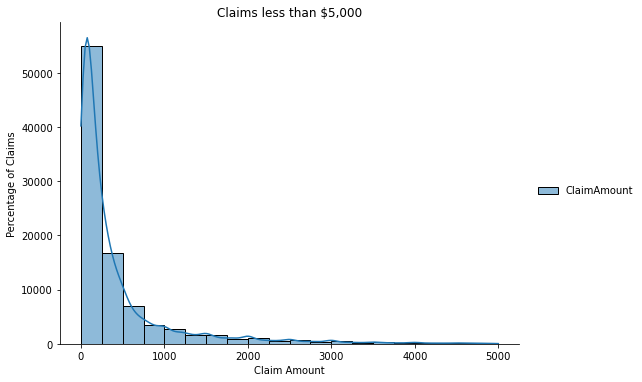

In [16]:
# Use a distribution plot for all claims that are less than 5,000
g = sns.displot(data=tsaClaims[['ClaimAmount']].query('ClaimAmount < 5000'), 
                kind='hist', aspect=1.5, bins=20, kde=True)
for ax in g.axes.flat:
    ax.set(title='Claims less than $5,000', ylabel='Percentage of Claims', xlabel='Claim Amount')

#### The typical claim is less than $250.

### What percent of claims are approved?

In [17]:
approvalRate = tsaClaims.groupby('Status').ClaimNumber.count().reset_index()
approvalRate.head()

,Status,ClaimNumber
0,Approved,23167
1,Canceled,6
2,Denied,53273
3,Pending response from claimant,1
4,Settled,18401


In [18]:
approvalRate['Percent'] = approvalRate.ClaimNumber / tsaClaims.ClaimNumber.count() * 100
approvalRate.head()

,Status,ClaimNumber,Percent
0,Approved,23167,24.425396
1,Canceled,6,0.006326
2,Denied,53273,56.166709
3,Pending response from claimant,1,0.001054
4,Settled,18401,19.400515


#### 24% of claims are approved.